## Cell 0 — Install Dependencies (run once, then restart kernel)

In [1]:
import subprocess, sys

# Uncomment if PyTorch not yet installed with CUDA:
# subprocess.run([sys.executable,'-m','pip','install','-q',
#     'torch','torchaudio','--index-url','https://download.pytorch.org/whl/cu118'])

pkgs = [
    'transformers==4.40.2',
    'accelerate==0.30.1',
    'evaluate==0.4.1',
    'jiwer==3.0.3',
    'librosa==0.10.1',
    'soundfile==0.12.1',
    'gradio==4.31.5',
    'seaborn',
]
for p in pkgs:
    r = subprocess.run([sys.executable,'-m','pip','install','-q',p],
                       capture_output=True, text=True)
    print(('✅' if r.returncode==0 else '❌'), p)

print('\n⚠️  RESTART KERNEL, then run from Cell 1 downward')

✅ transformers==4.40.2
✅ accelerate==0.30.1
✅ evaluate==0.4.1
✅ jiwer==3.0.3
✅ librosa==0.10.1
✅ soundfile==0.12.1
✅ gradio==4.31.5
✅ seaborn

⚠️  RESTART KERNEL, then run from Cell 1 downward


## Cell 1 — Imports & GPU Check

In [2]:
import os, re, json, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from typing import List
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from transformers import (
    WhisperForConditionalGeneration,
    WhisperProcessor,
    get_linear_schedule_with_warmup,
)
import evaluate
from jiwer import wer, cer, compute_measures

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('='*55)
if torch.cuda.is_available():
    g = torch.cuda.get_device_properties(0)
    print(f'  GPU   : {g.name}')
    print(f'  VRAM  : {g.total_memory/1e9:.1f} GB')
    print(f'  CUDA  : {torch.version.cuda}')
else:
    print('  ⚠️  No GPU — CPU only (slow)')
print(f'  Device: {device}')
print('='*55)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'train':'#3498DB','eval':'#E74C3C','accent':'#2ECC71','warn':'#E67E22'}
print('\n✅ Imports done')

  GPU   : NVIDIA GeForce RTX 3060 Laptop GPU
  VRAM  : 6.4 GB
  CUDA  : 12.1
  Device: cuda

✅ Imports done


## Cell 2 — Configuration  ← EDIT `DATA_DIR`

In [4]:
# ╔══════════════════════════════════════════════════════╗
# ║   ⚙️  ONLY EDIT THIS CELL                            ║
# ╚══════════════════════════════════════════════════════╝

DATA_DIR = r"C:\it's me\E-JUST\NN\Speech to Text Project\cv-corpus-24.0-2025-12-05\ar"

OUTPUT_DIR  = 'models/whisper-arabic'
RESULTS_DIR = 'results'

# whisper-small = 244M params — best for 6GB GPU
# whisper-tiny  =  39M params — fallback if OOM
BASE_MODEL = 'openai/whisper-small'

MAX_TRAIN_SAMPLES = 20000 
MAX_EVAL_SAMPLES  = 1000    
MAX_TEST_SAMPLES  = 1000    
TARGET_SR         = 16000
MAX_AUDIO_SEC     = 30.0

TRAIN_BATCH_SIZE = 4     # 4 is safe for 6GB with fp16 + frozen encoder
EVAL_BATCH_SIZE  = 8
GRAD_ACCUM       = 2     # effective batch = 8
NUM_EPOCHS       = 10
LEARNING_RATE    = 1e-5
WARMUP_STEPS     = 100
SEED             = 42
FREEZE_ENCODER   = True  # freeze CNN + Transformer encoder

torch.manual_seed(SEED)
np.random.seed(SEED)
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Config ready')
print(f'  Data          : {DATA_DIR}')
print(f'  Model         : {BASE_MODEL}')
print(f'  Train samples : {MAX_TRAIN_SAMPLES:,}')
print(f'  Epochs        : {NUM_EPOCHS}')
print(f'  Eff. batch    : {TRAIN_BATCH_SIZE * GRAD_ACCUM}')
print(f'  Freeze encoder: {FREEZE_ENCODER}')

Config ready
  Data          : C:\it's me\E-JUST\NN\Speech to Text Project\cv-corpus-24.0-2025-12-05\ar
  Model         : openai/whisper-small
  Train samples : 20,000
  Epochs        : 10
  Eff. batch    : 8
  Freeze encoder: True


## Cell 3 — Data Loading & Arabic Normalization

In [5]:
def normalize_arabic(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'[\u0610-\u061A\u064B-\u065F]', '', text)  # diacritics
    text = re.sub(r'[أإآ]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ـ', '', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def load_split(tsv_path, clips_dir, max_samples):
    df = pd.read_csv(tsv_path, sep='\t', low_memory=False)[['path','sentence']].dropna()
    df['audio_path'] = df['path'].apply(lambda p: str(Path(clips_dir)/p))
    df['sentence']   = df['sentence'].apply(normalize_arabic)
    df = df[df['sentence'].str.len().between(3, 150)]
    df = df[df['audio_path'].apply(os.path.exists)]
    if max_samples and len(df) > max_samples:
        df = df.sample(n=max_samples, random_state=SEED)
    return df.reset_index(drop=True)

data_dir  = Path(DATA_DIR)
clips_dir = data_dir / 'clips'

print('Loading TSV splits...')
df_train = load_split(data_dir/'train.tsv', clips_dir, MAX_TRAIN_SAMPLES)
df_dev   = load_split(data_dir/'dev.tsv',   clips_dir, MAX_EVAL_SAMPLES)
df_test  = load_split(data_dir/'test.tsv',  clips_dir, MAX_TEST_SAMPLES)

print(f'  Train : {len(df_train):,}')
print(f'  Dev   : {len(df_dev):,}')
print(f'  Test  : {len(df_test):,}')
df_train.head(3)

Loading TSV splits...
  Train : 20,000
  Dev   : 1,000
  Test  : 1,000


,path,sentence,audio_path
0,common_voice_ar_24169026.mp3,تحدثت، لكن احدا لم يستمع الي,C:\it's me\E-JUST\NN\Speech to Text Project\cv...
1,common_voice_ar_24158992.mp3,اهو علي ما يرام؟,C:\it's me\E-JUST\NN\Speech to Text Project\cv...
2,common_voice_ar_24035009.mp3,نريد حلا سلميا,C:\it's me\E-JUST\NN\Speech to Text Project\cv...


## Cell 4 — Dataset Statistics

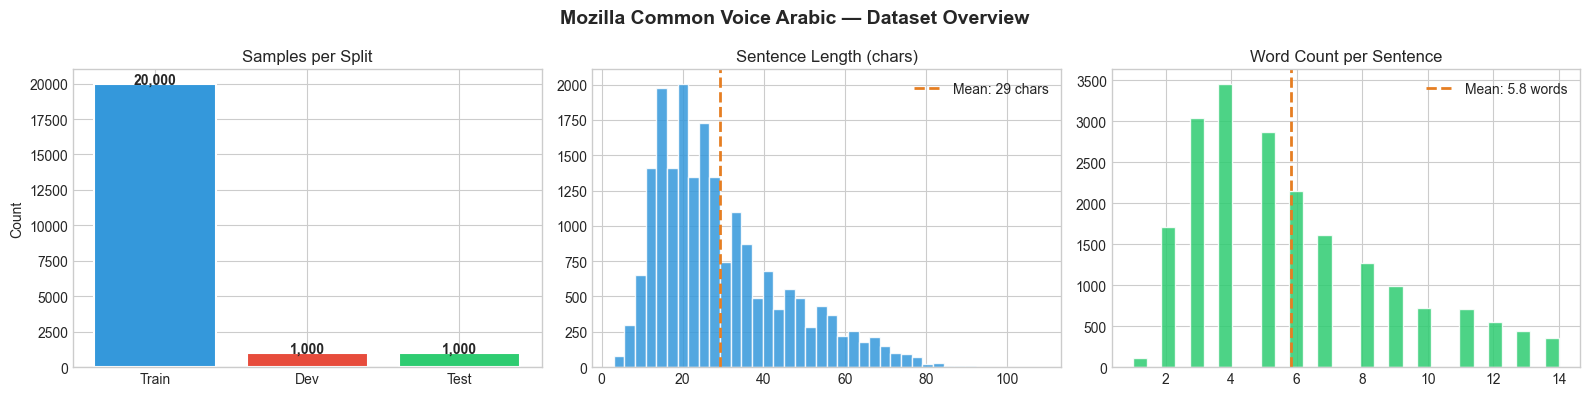

✅ Saved


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Mozilla Common Voice Arabic — Dataset Overview', fontsize=14, fontweight='bold')

bars = axes[0].bar(['Train','Dev','Test'], [len(df_train),len(df_dev),len(df_test)],
                   color=[COLORS['train'],COLORS['eval'],COLORS['accent']],
                   edgecolor='white', lw=1.5)
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+20,
                 f'{int(b.get_height()):,}', ha='center', fontweight='bold')
axes[0].set_title('Samples per Split'); axes[0].set_ylabel('Count')

lens = df_train['sentence'].str.len()
axes[1].hist(lens, bins=40, color=COLORS['train'], edgecolor='white', alpha=0.85)
axes[1].axvline(lens.mean(), color=COLORS['warn'], ls='--', lw=2,
                label=f'Mean: {lens.mean():.0f} chars')
axes[1].set_title('Sentence Length (chars)'); axes[1].legend()

wc = df_train['sentence'].str.split().str.len()
axes[2].hist(wc, bins=30, color=COLORS['accent'], edgecolor='white', alpha=0.85)
axes[2].axvline(wc.mean(), color=COLORS['warn'], ls='--', lw=2,
                label=f'Mean: {wc.mean():.1f} words')
axes[2].set_title('Word Count per Sentence'); axes[2].legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/dataset_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved')

## Cell 5 — Audio Visualization (Waveform + Log-Mel Spectrogram)

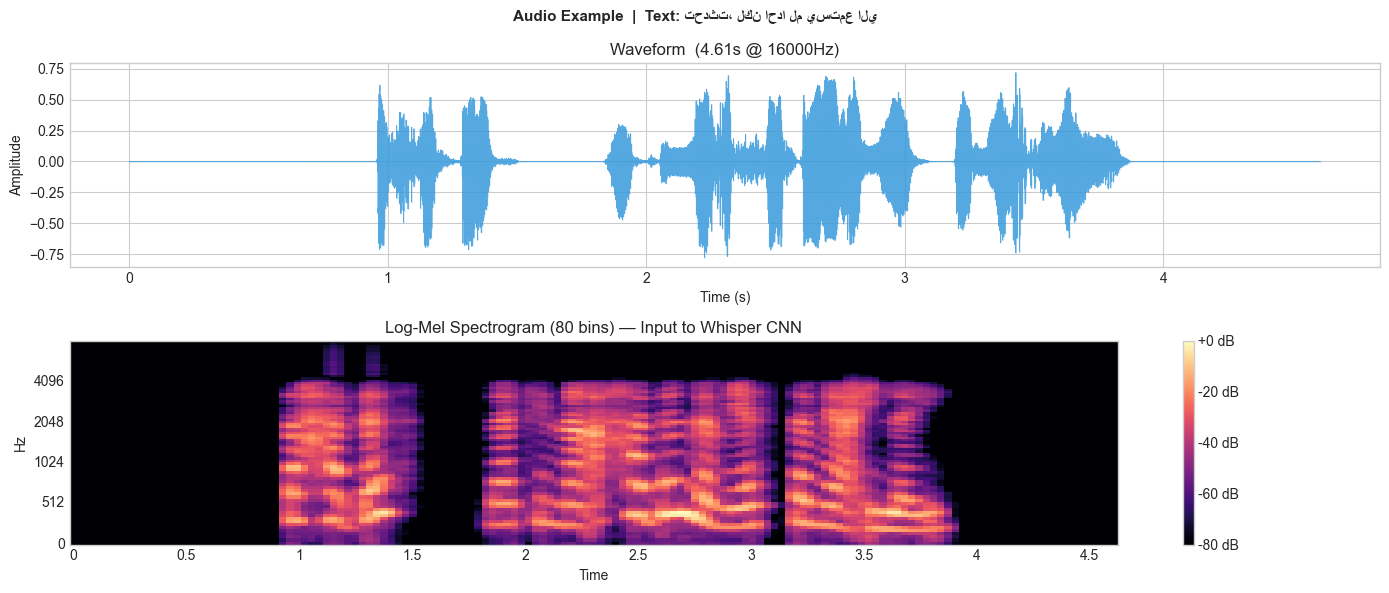

In [7]:
def load_audio(path, target_sr=TARGET_SR):
    try:
        audio, sr = sf.read(path)
        if audio.ndim > 1: audio = audio.mean(axis=1)
        audio = audio.astype(np.float32)
        if sr != target_sr:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        return audio
    except:
        return np.zeros(target_sr, dtype=np.float32)

sample = df_train.iloc[0]
audio  = load_audio(sample['audio_path'])
dur    = len(audio) / TARGET_SR

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle(f'Audio Example  |  Text: {sample["sentence"]}', fontsize=11, fontweight='bold')

t = np.linspace(0, dur, len(audio))
axes[0].plot(t, audio, color=COLORS['train'], lw=0.6, alpha=0.8)
axes[0].fill_between(t, audio, alpha=0.15, color=COLORS['train'])
axes[0].set_title(f'Waveform  ({dur:.2f}s @ {TARGET_SR}Hz)')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude')

mel    = librosa.feature.melspectrogram(y=audio, sr=TARGET_SR, n_mels=80, fmax=8000)
mel_db = librosa.power_to_db(mel, ref=np.max)
img    = librosa.display.specshow(mel_db, sr=TARGET_SR, x_axis='time',
                                   y_axis='mel', fmax=8000, ax=axes[1], cmap='magma')
plt.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set_title('Log-Mel Spectrogram (80 bins) — Input to Whisper CNN')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/audio_example.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — Architecture Diagram (CNN highlighted)

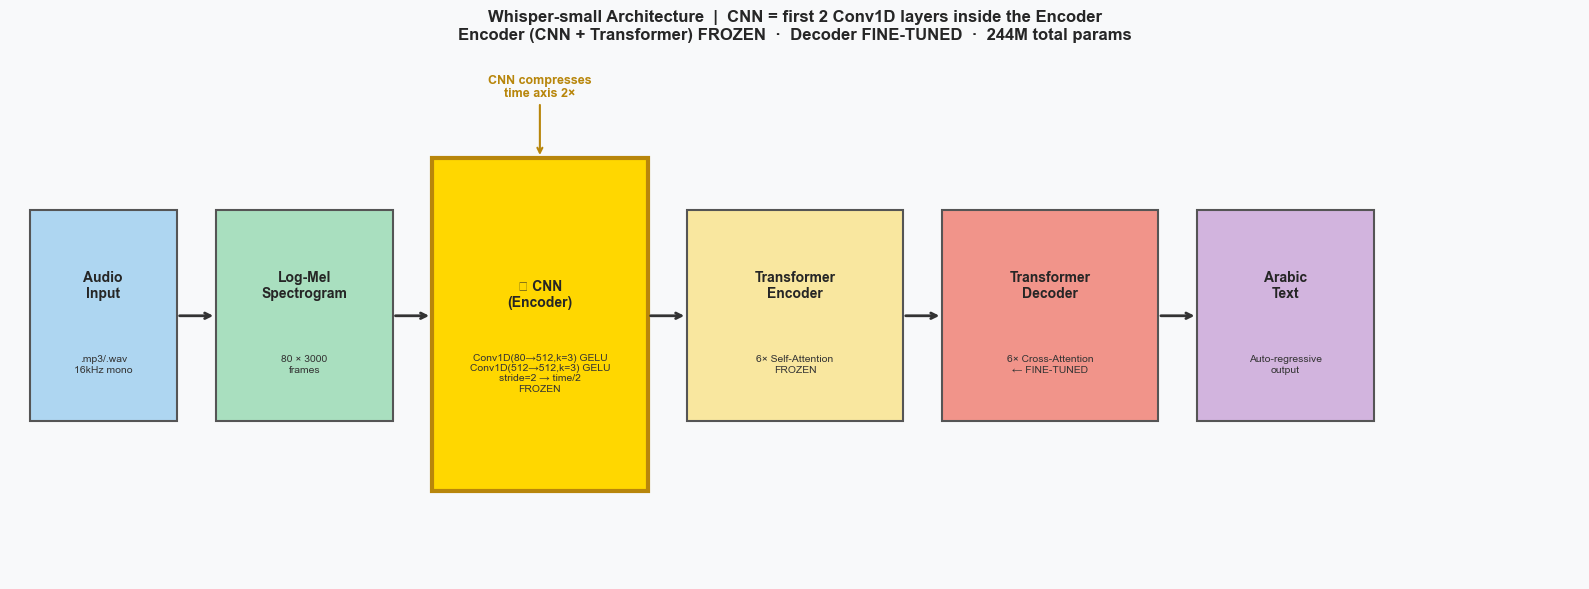

✅ Saved


In [8]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.set_xlim(0,16); ax.set_ylim(0,6)
ax.axis('off'); ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('#F8F9FA')

blocks = [
    (0.2, 1.8, 1.5, 2.4, '#AED6F1', 'Audio\nInput',           '.mp3/.wav\n16kHz mono'),
    (2.1, 1.8, 1.8, 2.4, '#A9DFBF', 'Log-Mel\nSpectrogram',  '80 × 3000\nframes'),
    (4.3, 1.0, 2.2, 3.8, '#FFD700', '🔶 CNN\n(Encoder)',      'Conv1D(80→512,k=3) GELU\nConv1D(512→512,k=3) GELU\nstride=2 → time/2\nFROZEN'),
    (6.9, 1.8, 2.2, 2.4, '#F9E79F', 'Transformer\nEncoder',  '6× Self-Attention\nFROZEN'),
    (9.5, 1.8, 2.2, 2.4, '#F1948A', 'Transformer\nDecoder',  '6× Cross-Attention\n← FINE-TUNED'),
    (12.1,1.8, 1.8, 2.4, '#D2B4DE', 'Arabic\nText',          'Auto-regressive\noutput'),
]

for x,y,w,h,color,title,sub in blocks:
    lw = 3.0 if 'CNN' in title else 1.5
    ec = '#B8860B' if 'CNN' in title else '#555'
    ax.add_patch(plt.Rectangle((x,y),w,h, facecolor=color,edgecolor=ec,linewidth=lw,zorder=2))
    ax.text(x+w/2, y+h/2+0.35, title, ha='center',va='center', fontsize=10,fontweight='bold',zorder=3)
    ax.text(x+w/2, y+h/2-0.55, sub,   ha='center',va='center', fontsize=7.5,color='#333',zorder=3)

ap = dict(arrowstyle='->',color='#333',lw=2)
for x1,x2 in [(1.7,2.1),(3.9,4.3),(6.5,6.9),(9.1,9.5),(11.7,12.1)]:
    ax.annotate('', xy=(x2,3.0), xytext=(x1,3.0), arrowprops=ap, zorder=4)

ax.annotate('CNN compresses\ntime axis 2×',
            xy=(5.4,4.8), xytext=(5.4,5.5),
            arrowprops=dict(arrowstyle='->',color='#B8860B',lw=1.5),
            fontsize=9, ha='center', color='#B8860B', fontweight='bold')

ax.set_title('Whisper-small Architecture  |  CNN = first 2 Conv1D layers inside the Encoder\n'
             'Encoder (CNN + Transformer) FROZEN  ·  Decoder FINE-TUNED  ·  244M total params',
             fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved')

## Cell 7 — Load Processor & Model

In [9]:
print(f'Loading {BASE_MODEL}...')
t0 = time.time()

processor = WhisperProcessor.from_pretrained(BASE_MODEL, language='arabic', task='transcribe')
model     = WhisperForConditionalGeneration.from_pretrained(BASE_MODEL)

if FREEZE_ENCODER:
    for p in model.model.encoder.parameters():
        p.requires_grad = False
    print('  Encoder FROZEN (CNN + Transformer encoder blocks)')

model = model.to(device)
from transformers import GenerationConfig
model.generation_config = GenerationConfig.from_pretrained(BASE_MODEL)
model.generation_config.language = 'arabic'
model.generation_config.task = 'transcribe'
model.generation_config.forced_decoder_ids = None

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'  Loaded in        : {time.time()-t0:.1f}s')
print(f'  Total params     : {total/1e6:.1f}M')
print(f'  Trainable params : {trainable/1e6:.1f}M  ({100*trainable/total:.1f}%)')
if torch.cuda.is_available():
    print(f'  VRAM used        : {torch.cuda.memory_allocated()/1e9:.2f} GB')

Loading openai/whisper-small...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


  Encoder FROZEN (CNN + Transformer encoder blocks)
  Loaded in        : 4.6s
  Total params     : 241.7M
  Trainable params : 153.6M  (63.5%)
  VRAM used        : 0.97 GB


## Cell 8 — Dataset & DataLoader

In [10]:
class ArabicDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment
        self.maxs    = int(MAX_AUDIO_SEC * TARGET_SR)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        audio = load_audio(row['audio_path'])[:self.maxs]

        if self.augment and np.random.random() < 0.3:
            audio = audio + np.random.randn(len(audio)).astype(np.float32) * 0.003

        # Always (80, 3000) — no variable length, no padding needed for features
        feats = processor.feature_extractor(
            audio, sampling_rate=TARGET_SR, return_tensors='pt'
        ).input_features[0]

        labels = processor.tokenizer(
            row['sentence'], return_tensors='pt', truncation=True, max_length=448
        ).input_ids[0]

        return {'input_features': feats, 'labels': labels}


def collate_fn(batch):
    feats  = torch.stack([b['input_features'] for b in batch])
    labels = [b['labels'] for b in batch]
    maxlen = max(l.size(0) for l in labels)
    pad    = torch.full((len(labels), maxlen), -100, dtype=torch.long)
    for i, l in enumerate(labels):
        pad[i, :l.size(0)] = l
    return {'input_features': feats, 'labels': pad}


train_ds = ArabicDataset(df_train, augment=True)
eval_ds  = ArabicDataset(df_dev,   augment=False)
test_ds  = ArabicDataset(df_test,  augment=False)

# num_workers=0 avoids Windows multiprocessing deadlocks
# NO group_by_length — Whisper features are always fixed 80×3000
train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
eval_loader  = DataLoader(eval_ds,  batch_size=EVAL_BATCH_SIZE,  shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=EVAL_BATCH_SIZE,  shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)

b = next(iter(train_loader))
print('✅ DataLoaders ready')
print(f'   input_features : {b["input_features"].shape}')   # expect (4, 80, 3000)
print(f'   labels         : {b["labels"].shape}')
print(f'   Train batches  : {len(train_loader)}')

✅ DataLoaders ready
   input_features : torch.Size([4, 80, 3000])
   labels         : torch.Size([4, 24])
   Train batches  : 5000


## Cell 9 — Optimizer, Scheduler, Scaler

In [11]:
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=0.01
)
total_steps = (len(train_loader) // GRAD_ACCUM) * NUM_EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=total_steps
)
scaler = GradScaler()

forced_decoder_ids = processor.get_decoder_prompt_ids(language='arabic', task='transcribe')

print('✅ Optimizer: AdamW')
print(f'   LR             : {LEARNING_RATE}')
print(f'   Total steps    : {total_steps}')
print(f'   Warmup steps   : {WARMUP_STEPS}')
print(f'   Eff. batch     : {TRAIN_BATCH_SIZE * GRAD_ACCUM}')
print(f'   fp16 scaler    : enabled')

✅ Optimizer: AdamW
   LR             : 1e-05
   Total steps    : 25000
   Warmup steps   : 100
   Eff. batch     : 8
   fp16 scaler    : enabled


## Cell 10 — 🚀 TRAINING  (live tqdm progress — step loss visible every iteration)

In [12]:
wer_metric = evaluate.load('wer')


def run_eval(loader, name='eval'):
    model.eval()
    refs, hyps, total_loss, n = [], [], 0.0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'  {name}', leave=False):
            feats  = batch['input_features'].to(device)
            labels = batch['labels'].to(device)
            with autocast():
                out = model(input_features=feats, labels=labels)
            total_loss += out.loss.item(); n += 1

            pred_ids = model.generate(feats, forced_decoder_ids=forced_decoder_ids,
                                      max_new_tokens=128)
            lids = labels.clone()
            lids[lids == -100] = processor.tokenizer.pad_token_id
            hyps.extend(processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True))
            refs.extend(processor.tokenizer.batch_decode(lids,     skip_special_tokens=True))

    wer_score = wer_metric.compute(predictions=hyps, references=refs)
    return total_loss / max(n,1), wer_score


history      = {'train_loss':[],'train_step':[],'eval_loss':[],'eval_wer':[],'epoch':[]}
best_wer     = float('inf')
best_epoch   = 0
global_step  = 0
t0           = time.time()

print(f'🚀 Training — {NUM_EPOCHS} epochs · {len(train_loader)} batches/epoch')
print(f'   Every step: loss shown in tqdm bar')
print(f'   Every epoch: WER printed immediately')
print('─'*60)

for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    ep_loss, ep_steps = 0.0, 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}', leave=True)

    for step, batch in enumerate(pbar, 1):
        feats  = batch['input_features'].to(device)
        labels = batch['labels'].to(device)

        with autocast():
            out  = model(input_features=feats, labels=labels)
            loss = out.loss / GRAD_ACCUM

        scaler.scale(loss).backward()

        if step % GRAD_ACCUM == 0 or step == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0
            )
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

        raw = out.loss.item()
        ep_loss += raw; ep_steps += 1

        history['train_loss'].append(raw)
        history['train_step'].append(global_step)

        pbar.set_postfix(loss=f'{raw:.4f}',
                         avg=f'{ep_loss/ep_steps:.4f}',
                         lr=f'{scheduler.get_last_lr()[0]:.2e}')

    # ── Epoch end ─────────────────────────────────────────────────────────────
    eval_loss, eval_wer_score = run_eval(eval_loader, 'dev')

    history['eval_loss'].append(eval_loss)
    history['eval_wer'].append(eval_wer_score)
    history['epoch'].append(epoch)

    elapsed = (time.time()-t0)/3600
    avg_train = ep_loss/ep_steps

    print(f'\n  ── Epoch {epoch}/{NUM_EPOCHS} ──────────────────────────────────')
    print(f'     Train loss : {avg_train:.4f}')
    print(f'     Val   loss : {eval_loss:.4f}')
    print(f'     Val   WER  : {eval_wer_score*100:.2f}%')
    print(f'     Elapsed    : {elapsed:.2f}h')

    if eval_wer_score < best_wer:
        best_wer, best_epoch = eval_wer_score, epoch
        model.save_pretrained(f'{OUTPUT_DIR}/best')
        processor.save_pretrained(f'{OUTPUT_DIR}/best')
        print(f'     ✅ Best model saved  (WER={best_wer*100:.2f}%)')
    print()

total_h = (time.time()-t0)/3600
print('='*55)
print(f'✅ Done in {total_h:.2f}h  |  Best WER: {best_wer*100:.2f}%  epoch {best_epoch}')
model.save_pretrained(f'{OUTPUT_DIR}/final')
processor.save_pretrained(f'{OUTPUT_DIR}/final')
json.dump(history, open(f'{OUTPUT_DIR}/history.json','w'))
print(f'   Models → {OUTPUT_DIR}/best  &  {OUTPUT_DIR}/final')

Using the latest cached version of the module from C:\Users\Lenovo\.cache\huggingface\modules\evaluate_modules\metrics\evaluate-metric--wer\e41eaa77ca7152430cd94704de20946c1b004b5b488ab5d20b26fb81c6c15506 (last modified on Mon May  4 00:22:05 2026) since it couldn't be found locally at evaluate-metric--wer, or remotely on the Hugging Face Hub.


🚀 Training — 10 epochs · 5000 batches/epoch
   Every step: loss shown in tqdm bar
   Every epoch: WER printed immediately
────────────────────────────────────────────────────────────


Epoch 1/10:   0%|          | 0/5000 [00:00<?, ?it/s]

  dev:   0%|          | 0/125 [00:00<?, ?it/s]

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}


...


  ── Epoch 9/10 ──────────────────────────────────
     Train loss : 0.0060
     Val   loss : 0.3207
     Val   WER  : 24.24%
     Elapsed    : 3.42h
     ✅ Best model saved  (WER=24.24%)



Epoch 10/10:   0%|          | 0/5000 [00:00<?, ?it/s]

  dev:   0%|          | 0/125 [00:00<?, ?it/s]

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}



  ── Epoch 10/10 ──────────────────────────────────
     Train loss : 0.0049
     Val   loss : 0.3225
     Val   WER  : 25.14%
     Elapsed    : 3.79h

✅ Done in 3.79h  |  Best WER: 24.24%  epoch 9
   Models → models/whisper-arabic/best  &  models/whisper-arabic/final


## Cell 11 — Training Curves

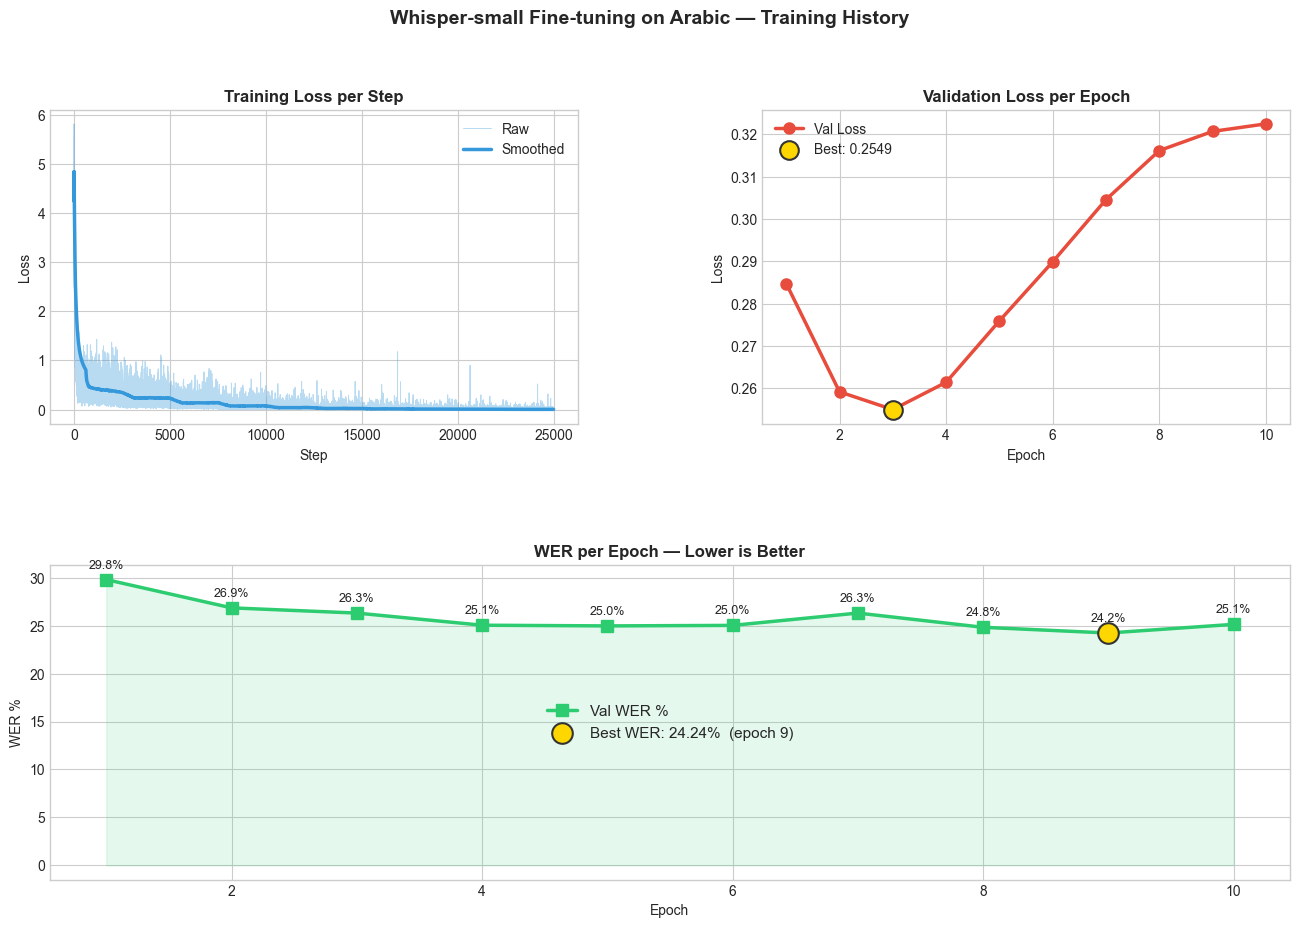

✅ Saved


In [13]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0,0])
steps  = history['train_step']
losses = history['train_loss']
ax1.plot(steps, losses, color=COLORS['train'], lw=0.7, alpha=0.35, label='Raw')
if len(losses) > 10:
    sm = pd.Series(losses).rolling(max(len(losses)//40,5), min_periods=1).mean()
    ax1.plot(steps, sm.values, color=COLORS['train'], lw=2.5, label='Smoothed')
ax1.set_title('Training Loss per Step', fontsize=12, fontweight='bold')
ax1.set_xlabel('Step'); ax1.set_ylabel('Loss'); ax1.legend()

ax2 = fig.add_subplot(gs[0,1])
ep_x = history['epoch']; el = history['eval_loss']
ax2.plot(ep_x, el, color=COLORS['eval'], lw=2.5, marker='o', markersize=8, label='Val Loss')
bi = int(np.argmin(el))
ax2.scatter([ep_x[bi]], [el[bi]], color='gold', s=180, zorder=5, edgecolors='#333', lw=1.5,
            label=f'Best: {el[bi]:.4f}')
ax2.set_title('Validation Loss per Epoch', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend()

ax3 = fig.add_subplot(gs[1,:])
wers = history['eval_wer']
ax3.plot(ep_x, [w*100 for w in wers], color=COLORS['accent'], lw=2.5,
         marker='s', markersize=9, label='Val WER %')
ax3.fill_between(ep_x, [w*100 for w in wers], alpha=0.12, color=COLORS['accent'])
bwi = int(np.argmin(wers))
ax3.scatter([ep_x[bwi]], [wers[bwi]*100], color='gold', s=220, zorder=5,
            edgecolors='#333', lw=1.5,
            label=f'Best WER: {wers[bwi]*100:.2f}%  (epoch {ep_x[bwi]})')
for e, w_val in zip(ep_x, wers):
    ax3.annotate(f'{w_val*100:.1f}%', xy=(e, w_val*100),
                 xytext=(e, w_val*100 + max(wers)*100*0.04),
                 ha='center', fontsize=9)
ax3.set_title('WER per Epoch — Lower is Better', fontsize=12, fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('WER %'); ax3.legend(fontsize=11)

fig.suptitle('Whisper-small Fine-tuning on Arabic — Training History',
             fontsize=14, fontweight='bold')
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved')

## Cell 12 — Test Set Evaluation

In [14]:
print('Loading best checkpoint for test evaluation...')
model = WhisperForConditionalGeneration.from_pretrained(f'{OUTPUT_DIR}/best').to(device)
model.eval()

references, hypotheses = [], []
for batch in tqdm(test_loader, desc='Testing'):
    feats  = batch['input_features'].to(device)
    lids   = batch['labels'].clone()
    lids[lids == -100] = processor.tokenizer.pad_token_id

    with torch.no_grad():
        pred_ids = model.generate(feats, forced_decoder_ids=forced_decoder_ids,
                                  max_new_tokens=128)

    hypotheses.extend(processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True))
    references.extend(processor.tokenizer.batch_decode(lids,     skip_special_tokens=True))

measures  = compute_measures(references, hypotheses)
wer_score = measures['wer']
cer_score = cer(references, hypotheses)
total_w   = measures['hits'] + measures['substitutions'] + measures['deletions']

metrics = {
    'wer': round(wer_score,4), 'cer': round(cer_score,4),
    'hits': measures['hits'], 'substitutions': measures['substitutions'],
    'deletions': measures['deletions'], 'insertions': measures['insertions'],
    'total_words': total_w,
}

print(f'\n{"="*50}')
print(f'  WER           : {wer_score*100:.2f}%')
print(f'  CER           : {cer_score*100:.2f}%')
print(f'  Correct words : {measures["hits"]:,}  ({100*measures["hits"]/total_w:.1f}%)')
print(f'  Substitutions : {measures["substitutions"]:,}')
print(f'  Deletions     : {measures["deletions"]:,}')
print(f'  Insertions    : {measures["insertions"]:,}')
print(f'{"="*50}')

df_results = pd.DataFrame({'reference': references, 'hypothesis': hypotheses})
df_results['sample_wer'] = df_results.apply(
    lambda r: wer(r['reference'], r['hypothesis']) if r['reference'].strip() else 1.0, axis=1
)
df_results.to_csv(f'{RESULTS_DIR}/test_results.csv', index=False, encoding='utf-8-sig')
json.dump(metrics, open(f'{RESULTS_DIR}/metrics.json','w'), indent=2)
print('\n✅ Saved test_results.csv + metrics.json')

Loading best checkpoint for test evaluation...


Testing:   0%|          | 0/125 [00:00<?, ?it/s]


  WER           : 32.15%
  CER           : 11.14%
  Correct words : 3,671  (70.4%)
  Substitutions : 1,377
  Deletions     : 165
  Insertions    : 134

✅ Saved test_results.csv + metrics.json


## Cell 13 — Results Visualization

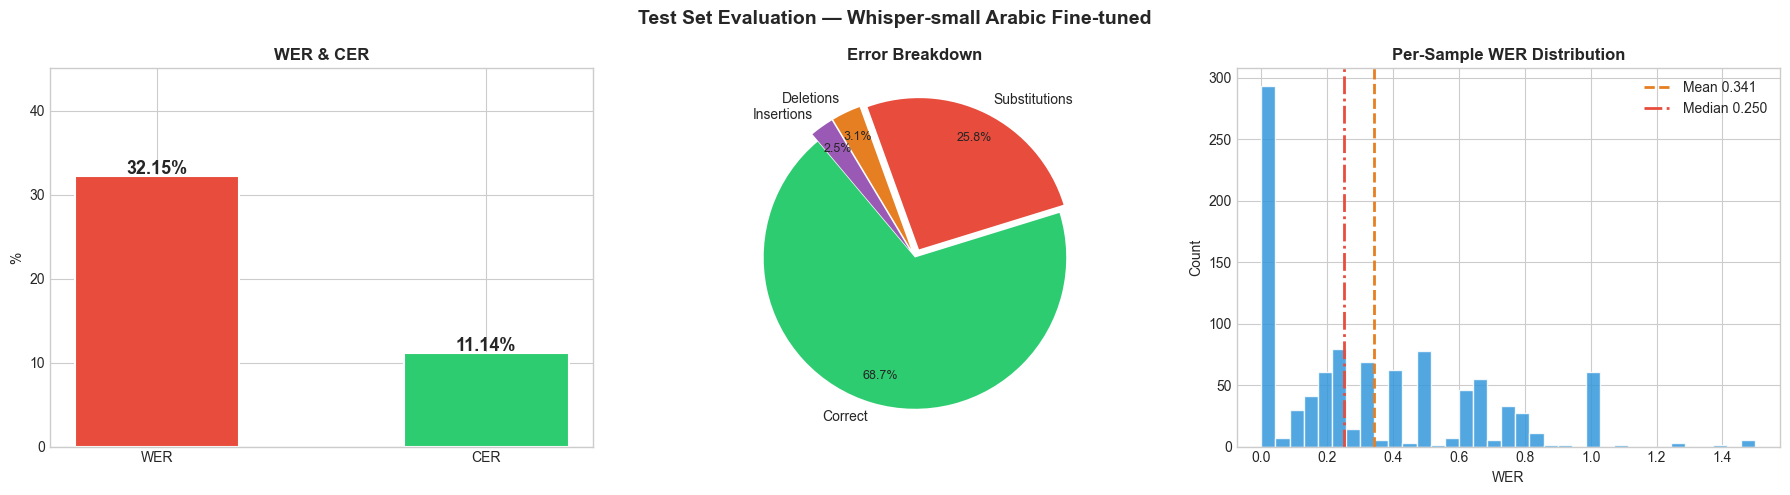

✅ Saved


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Test Set Evaluation — Whisper-small Arabic Fine-tuned', fontsize=14, fontweight='bold')

bars = axes[0].bar(['WER','CER'], [wer_score*100, cer_score*100],
                   color=[COLORS['eval'],COLORS['accent']], edgecolor='white', lw=1.5, width=0.5)
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f'{b.get_height():.2f}%', ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, max(wer_score,cer_score)*140)
axes[0].set_title('WER & CER', fontsize=12, fontweight='bold'); axes[0].set_ylabel('%')

sizes   = [measures['hits'],measures['substitutions'],measures['deletions'],measures['insertions']]
labels  = ['Correct','Substitutions','Deletions','Insertions']
colors  = ['#2ECC71','#E74C3C','#E67E22','#9B59B6']
wedges, texts, autotexts = axes[1].pie(sizes, labels=labels, colors=colors, explode=(0,.06,.06,.06),
                                        autopct='%1.1f%%', startangle=130, pctdistance=0.82)
for at in autotexts: at.set_fontsize(9)
axes[1].set_title('Error Breakdown', fontsize=12, fontweight='bold')

wc = df_results['sample_wer'].clip(upper=1.5)
axes[2].hist(wc, bins=35, color=COLORS['train'], edgecolor='white', alpha=0.85)
axes[2].axvline(df_results['sample_wer'].mean(), color=COLORS['warn'], ls='--', lw=2,
                label=f'Mean {df_results["sample_wer"].mean():.3f}')
axes[2].axvline(df_results['sample_wer'].median(), color=COLORS['eval'], ls='-.', lw=2,
                label=f'Median {df_results["sample_wer"].median():.3f}')
axes[2].set_title('Per-Sample WER Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('WER'); axes[2].set_ylabel('Count'); axes[2].legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved')

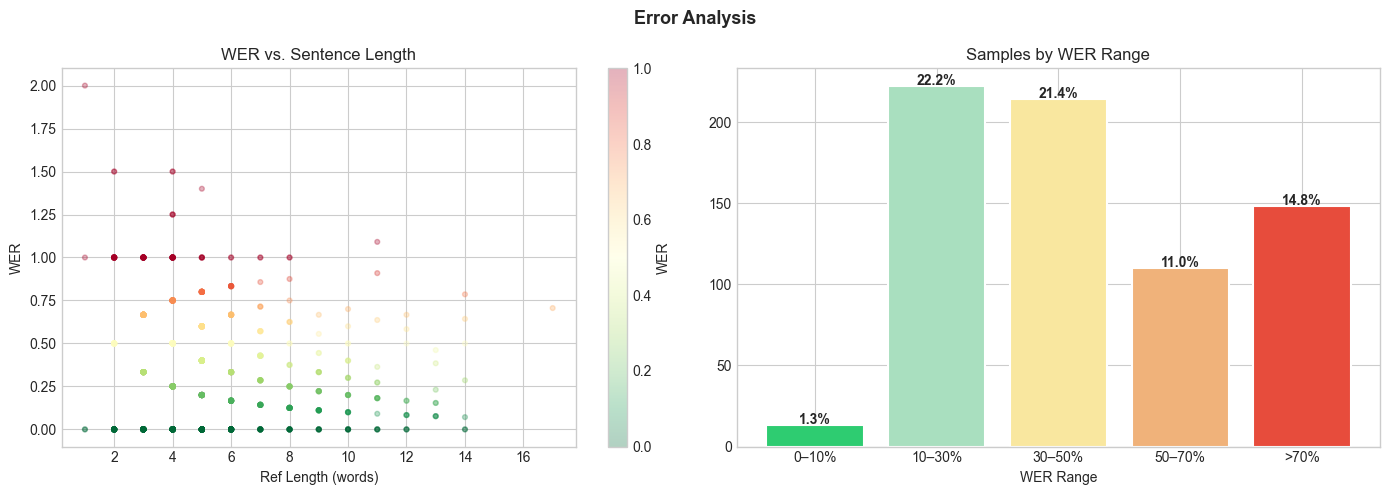

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis', fontsize=13, fontweight='bold')

ref_lens = [len(r.split()) for r in references]
sc = axes[0].scatter(ref_lens, df_results['sample_wer'], alpha=0.3, s=12,
                     c=df_results['sample_wer'], cmap='RdYlGn_r', vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[0], label='WER')
axes[0].set_xlabel('Ref Length (words)'); axes[0].set_ylabel('WER')
axes[0].set_title('WER vs. Sentence Length')

df_results['wer_bucket'] = pd.cut(df_results['sample_wer'],
    bins=[0,.1,.3,.5,.7,2.0], labels=['0–10%','10–30%','30–50%','50–70%','>70%'])
bc = df_results['wer_bucket'].value_counts().sort_index()
b2 = axes[1].bar(bc.index.astype(str), bc.values,
                 color=['#2ECC71','#A9DFBF','#F9E79F','#F0B27A','#E74C3C'],
                 edgecolor='white', lw=1.5)
for b in b2:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+1,
                 f'{100*b.get_height()/len(df_results):.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Samples by WER Range'); axes[1].set_xlabel('WER Range')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

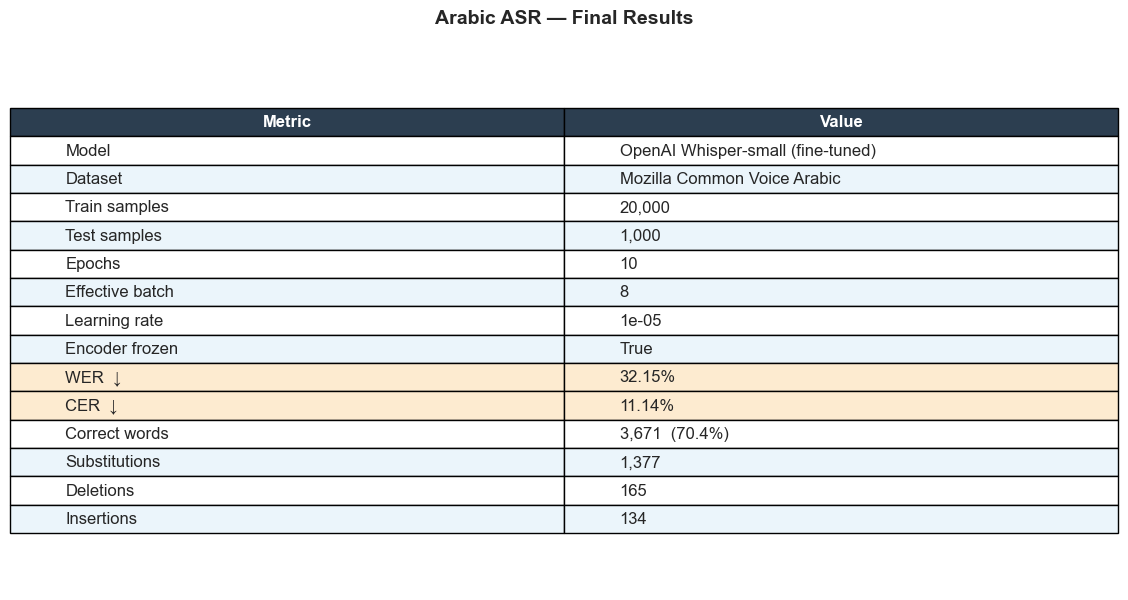

✅ Saved


In [17]:
fig, ax = plt.subplots(figsize=(11, 7)); ax.axis('off')

rows = [
    ['Model',            'OpenAI Whisper-small (fine-tuned)'],
    ['Dataset',          'Mozilla Common Voice Arabic'],
    ['Train samples',    f'{len(train_ds):,}'],
    ['Test samples',     f'{len(test_ds):,}'],
    ['Epochs',           str(NUM_EPOCHS)],
    ['Effective batch',  str(TRAIN_BATCH_SIZE * GRAD_ACCUM)],
    ['Learning rate',    str(LEARNING_RATE)],
    ['Encoder frozen',   str(FREEZE_ENCODER)],
    ['WER  ↓',          f'{wer_score*100:.2f}%'],
    ['CER  ↓',          f'{cer_score*100:.2f}%'],
    ['Correct words',    f"{measures['hits']:,}  ({100*measures['hits']/total_w:.1f}%)"],
    ['Substitutions',    f"{measures['substitutions']:,}"],
    ['Deletions',        f"{measures['deletions']:,}"],
    ['Insertions',       f"{measures['insertions']:,}"],
]

tbl = ax.table(cellText=rows, colLabels=['Metric','Value'], loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(12); tbl.scale(1.3,1.7)

for j in range(2):
    tbl[0,j].set_facecolor('#2C3E50')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(rows)+1):
    c = '#FDEBD0' if i in [9,10] else ('#EBF5FB' if i%2==0 else 'white')
    for j in range(2): tbl[i,j].set_facecolor(c)

ax.set_title('Arabic ASR — Final Results', fontsize=14, fontweight='bold', pad=20)
plt.savefig(f'{RESULTS_DIR}/summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved')

## Cell 14 — Best & Worst Predictions

In [18]:
best  = df_results.nsmallest(5,'sample_wer')
worst = df_results.nlargest(5,'sample_wer')

print('🟢 BEST 5')
for _,r in best.iterrows():
    print(f'  REF: {r["reference"]}'); print(f'  HYP: {r["hypothesis"]}')
    print(f'  WER: {r["sample_wer"]:.3f}\n')

print('🔴 WORST 5')
for _,r in worst.iterrows():
    print(f'  REF: {r["reference"]}'); print(f'  HYP: {r["hypothesis"]}')
    print(f'  WER: {r["sample_wer"]:.3f}\n')

🟢 BEST 5
  REF: لانه قد تقدم من كلام الحكماء
  HYP: لانه قد تقدم من كلام الحكماء
  WER: 0.000

  REF: ذهبت الي السينما مع اخي
  HYP: ذهبت الي السينما مع اخي
  WER: 0.000

  REF: السيدات اولا
  HYP: السيدات اولا
  WER: 0.000

  REF: صدني بعد اقتراب وجفاني
  HYP: صدني بعد اقتراب وجفاني
  WER: 0.000

  REF: يجب ان اذهب
  HYP: يجب ان اذهب
  WER: 0.000

🔴 WORST 5
  REF: هجاء
  HYP: هي جاء
  WER: 2.000

  REF: ايهذا المعيربي حيث وردي
  HYP: اي هذا المعير بحيث هو اريد
  WER: 1.500

  REF: عجبت دختنوس لما راتني
  HYP: عجبا ا اختلو اسلم ما راتنيه
  WER: 1.500

  REF: ملئت الحافله
  HYP: ملئه حياه لام
  WER: 1.500

  REF: وظف مناد
  HYP: واللف من نادي
  WER: 1.500



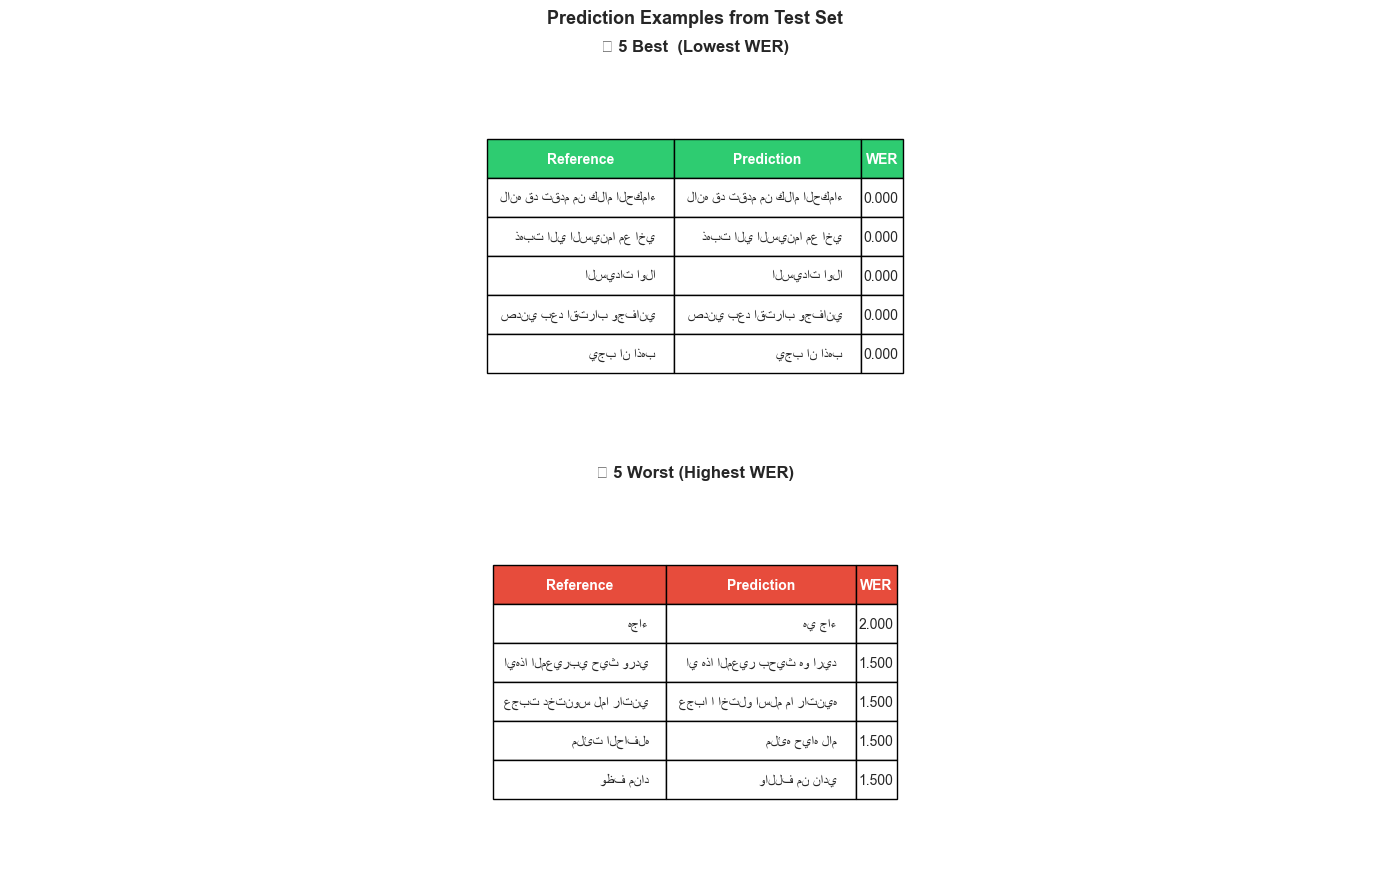

✅ Saved


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, df_sub, title, color in [
    (axes[0], best,  '🟢 5 Best  (Lowest WER)',   '#2ECC71'),
    (axes[1], worst, '🔴 5 Worst (Highest WER)',  '#E74C3C'),
]:
    ax.axis('off')
    rdata = []
    for _,r in df_sub.iterrows():
        ref = (r['reference'][:55]+'…') if len(r['reference'])>55 else r['reference']
        hyp = (r['hypothesis'][:55]+'…') if len(r['hypothesis'])>55 else r['hypothesis']
        rdata.append([ref, hyp, f"{r['sample_wer']:.3f}"])
    tbl = ax.table(cellText=rdata, colLabels=['Reference','Prediction','WER'],
                   loc='center', cellLoc='right')
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.0,1.9)
    tbl.auto_set_column_width([0,1,2])
    for j in range(3):
        tbl[0,j].set_facecolor(color)
        tbl[0,j].set_text_props(color='white', fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)

plt.suptitle('Prediction Examples from Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/prediction_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved')

## Cell 15 — Single File Inference

In [20]:
def transcribe(audio_path):
    audio = load_audio(audio_path)
    feats = processor.feature_extractor(audio, sampling_rate=TARGET_SR,
                                         return_tensors='pt').input_features.to(device)
    with torch.no_grad():
        ids = model.generate(feats, forced_decoder_ids=forced_decoder_ids, max_new_tokens=128)
    return processor.tokenizer.batch_decode(ids, skip_special_tokens=True)[0]

s    = df_test.sample(1, random_state=7).iloc[0]
pred = transcribe(s['audio_path'])
print('─'*60)
print(f'  REF : {s["sentence"]}')
print(f'  HYP : {pred}')
print(f'  WER : {wer(s["sentence"], pred):.3f}')
print('─'*60)

# Your own file:
# print(transcribe(r'C:\path\to\audio.mp3'))

────────────────────────────────────────────────────────────
  REF : واحد في الحمي فدته الوف
  HYP : واحد في الحما فدته اليوف
  WER : 0.400
────────────────────────────────────────────────────────────
